# Практическая работа № 1

**Цель работы:** познакомиться с базовыми принципами работы нейронных сетей и попробовать их на практике на простой задаче классификации.

**Задачи:**

1. Сгенерировать датасет, визуализировать и описать данные.
2. Создать простую нейронную сеть и
обучить модель.
3. Построить график функции потерь,
выбрать и рассчитать метрику качества,
описать как меняется обучение.
4. Построить две модели нейронной сети с использованием других гиперпараметров.
5. Визуализировать все результаты и описать их. Написать выводы к каждому эксперименту и графику.


---



**Теоретическая справка**

**Нейронная сеть** — это система адаптивных алгоритмов, структура которых отдаленно напоминает принципы работы биологических нейронов мозга. С математической точки зрения, это сложная функция, которая преобразует входные данные (признаки) в выходные (прогнозы). В задачах классификации нейросеть обучается находить такие границы в данных, которые позволяют максимально точно разделять объекты на группы.


Архитектура нейросети состоит из следующих элементов:

* Слои (Layers). Входной слой принимает числовые характеристики данных, скрытые слои выполняют основные вычисления, выходной слой формирует окончательный ответ.
* Веса ($W$). Параметры, определяющие важность каждого входящего сигнала. Обучение сети — это подбор оптимальных значений этих весов.
* Смещения ($b$). Дополнительные коэффициенты, позволяющие модели быть более гибкой и сдвигать границы активации.
* Нейрон. Базовая вычислительная единица, которая суммирует входные сигналы с их весами, добавляет смещение и пропускает результат через функцию активации:
$$y = f(\sum w_i x_i + b)$$

**Функция активации** вносит в модель нелинейность, благодаря чему сеть может строить сложные кривые границы между классами. Без неё нейросеть была бы набором линейных уравнений и не смогла бы решать сложные нелинейные задачи.

**Функция потерь** (Loss Function) — это математический способ измерить, насколько предсказание модели отличается от реального ответа. Чем меньше значение функции потерь, тем лучше обучена модель. Для задач бинарной классификации чаще всего используется Binary Cross Entropy.

**Оптимизатор** обновляет веса нейронов, используя метод градиентного спуска. Он вычисляет градиенты (направления наискорейшего роста ошибки) и делает шаг в противоположную сторону.



---



**Используемые инструменты**

* PyTorch — библиотека для построения нейронных сетей с автоматическим расчетом градиентов
* NumPy — инструмент для работы с массивами и математическими вычислениями
* Matplotlib / Seaborn — библиотеки для визуализации графиков и данных
* Scikit-learn — понадобится для генерации синтетического датасета и оценки метрик

In [2]:
# Используемые библиотеки
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import pandas as pd

## 1. Генерация и визуализация данных

Для решения задачи классификации возьмем синтетический датасет make_circles из библиотеки scikit-learn.

Датасет представляет собой две группы точек на плоскости, где одна находится внутри другой. Признаки: координаты для каждой точки. Метки: бинарная классификация (0
внешний круг, 1 внутренний). Данные являются линейно неразделимыми, невозможно провести одну прямую линию так, чтобы полностью отделить один класс от другого.

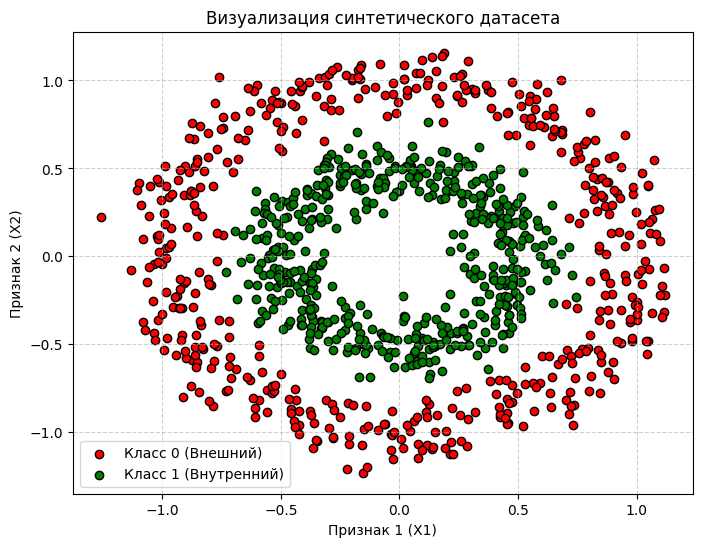

In [3]:
# Генерируем данные
X, y = make_circles(n_samples=1000, # количество точек
                    noise=0.1, # уровень шума
                    factor=0.5, # расстояние между кругами
                    random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Класс 0 (Внешний)', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='green', label='Класс 1 (Внутренний)', edgecolors='k')
plt.title("Визуализация синтетического датасета")
plt.xlabel("Признак 1 (X1)")
plt.ylabel("Признак 2 (X2)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Cгенерировали 1000 точек, которые образуют два круга.

PyTorch работает с тензорами, поэтому подготовим их и разделим данные на train и test.

In [4]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Построение простой нейронной сети

Для решения задачи создадим полносвязную нейронную сеть. Входной слой принимает 2 признака (координаты x1 и x2), скрытый слой 1 состоит из 10 нейронов с функцтей активации ReLU для внесения нелинейности, скрытый слой 2 также из 10 нейронов с активацией ReLU, выходной слой из 1 нейрона, который выдает число. После него сигмоида, чтобы получить вероятность принадлежности к классу.

Параметры обучения:
* Функция потерь:`BCEWithLogitsLoss` (бинарная кросс-энтропия, объединяющая слой сигмоиды и расчет ошибки).
* Оптимизатор: `SGD` (стохастический градиентный спуск) с переменной скоростью обучения (learning rate).
* Метрика качества: `Accuracy`. При отсутствии дисбаланса классов Accuracy является наиболее наглядным показателем качества классификации.



In [5]:
# Класс модели
class CircleModelV0(nn.Module):
    def __init__(self, hidden_units):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=hidden_units)
        self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer_3 = nn.Linear(in_features=hidden_units, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Проход данных через слои
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_0 = CircleModelV0(hidden_units=10)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

# Функция для расчета accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

Цикл обучения:

In [ ]:
torch.manual_seed(42)
epochs = 1000

loss_history = [] # для сохранения истории обучения

for epoch in range(epochs):
    model_0.train()

    # Прямой проход
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Расчет ошибки
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # Обнуление градиентов
    optimizer.zero_grad()

    # Обратный проход
    loss.backward()

    # Шаг оптимизатора
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 100 == 0:
        print(f"Эпоха: {epoch} | Ошибка (Loss): {loss.item():.5f}, Точность (Acc): {acc:.2f}%")

print("Обучение завершено")

Эпоха: 0 | Ошибка (Loss): 0.69646, Точность (Acc): 50.00%
Эпоха: 100 | Ошибка (Loss): 0.69215, Точность (Acc): 51.50%
Эпоха: 200 | Ошибка (Loss): 0.68973, Точность (Acc): 54.50%
Эпоха: 300 | Ошибка (Loss): 0.68516, Точность (Acc): 55.88%
Эпоха: 400 | Ошибка (Loss): 0.67295, Точность (Acc): 61.00%
Эпоха: 500 | Ошибка (Loss): 0.62431, Точность (Acc): 79.75%
Эпоха: 600 | Ошибка (Loss): 0.45032, Точность (Acc): 97.12%
Эпоха: 700 | Ошибка (Loss): 0.18775, Точность (Acc): 99.38%
Эпоха: 800 | Ошибка (Loss): 0.08740, Точность (Acc): 99.50%
Эпоха: 900 | Ошибка (Loss): 0.05419, Точность (Acc): 99.50%
Обучение завершено


На старте точность составила 50%, равная случайному угадыванию. К 600-й эпохе точность резко выросла до 97% и к концу обучения достигла 99.5%, что говорит о практически безошибочном разделении классов.

Построим график функции потерь, а также для наглядности посмотрим, как нейросеть научилась проводить границу.

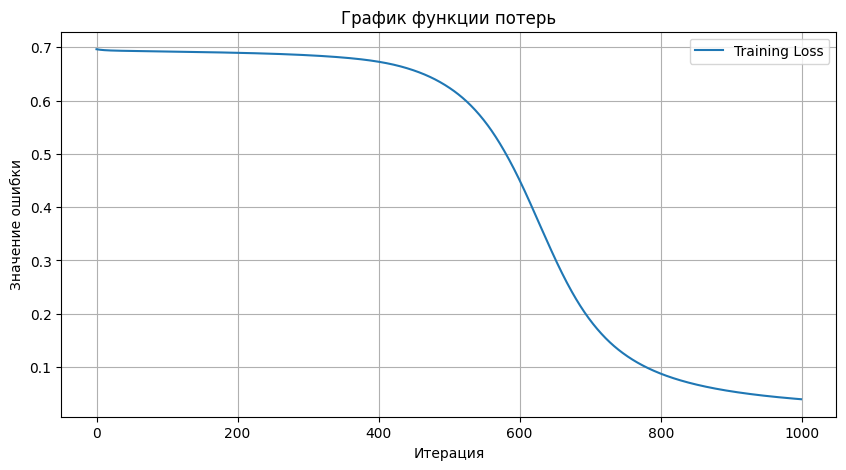

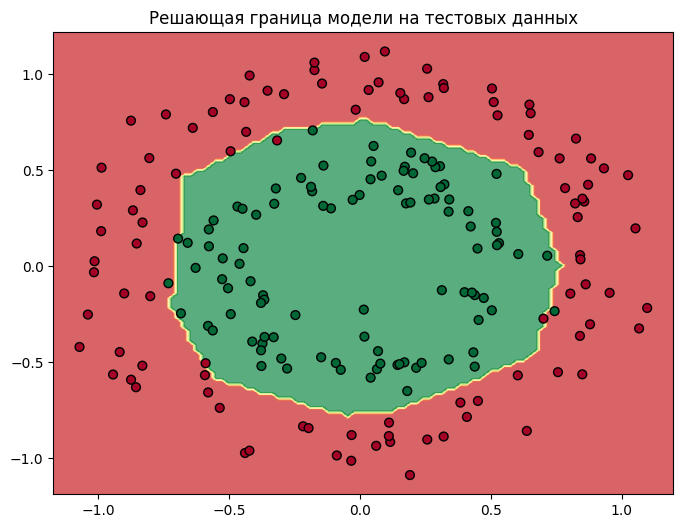

In [ ]:
# Функция потерь
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label="Training Loss")
plt.title("График функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Значение ошибки")
plt.legend()
plt.grid(True)
plt.show()

# Визуализация решающей границы
def plot_decision_boundary(model, X, y):
    # определяем края графика через минимальные и максимальные координаты
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    # создаем координатную сетку
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # переводим сетку в тензор для нейросети
    X_to_pred_on = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    # отключаем обучение, модель в режиме оценки
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)
    # обработка ответов
    y_pred = torch.round(torch.sigmoid(y_logits)).reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlGn, alpha=0.7)
    # накладываем на полученный фон реальные точки тестового набора
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlGn, edgecolors='k')

plt.figure(figsize=(8, 6))
plot_decision_boundary(model_0, X_test, y_test)
plt.title("Решающая граница модели на тестовых данных")
plt.show()

График функции потерь: в начале обучения ошибка снижалась медленно, так как веса задавались случайно. В диапазоне между 500-700 итерациями произошел резкий спад, когда сеть начала активно подбирать нужную форму решающей границы. К 1000-й итерации график выходит на плато, значение ошибки около нуля. Модель успешно сошлась и дальнейшее обучение вряд-ли принесет значительные улучшения.

График решающей границы: нейросеть построила замкнутую область вокруг внутренней группы, почти все точки попали в свои цветовые зоны. Модель выучила нелинейную зависимость. ReLU строит кусочно-линейные границы, чем больше нейронов в слое, тем более гладкой и похожей на круг будет граница.

Базовая модель с двумя скрытыми слоями по 10 нейронов показала высокую эффективность и успешно решила задачу классификации для линейно неразделимого датасета.

Расчитаем финальное значение точности на тестовых данных.

In [ ]:
# модель в режим оценки
model_0.eval()

with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

print(f"Accuracy на тестовых данных: {test_acc:.2f}%")

Accuracy на тестовых данных: 97.50%


Точность очень высокая, как и при обучении, значит нет переобучения. Модель поняла геометрию данных.

## 3. Изменение гиперпараметров

Для изучения влияния настроек нейросети на качество обучения проведем серию экспериментов.

Гиперпараметры, которые будем менять:
1. Learning Rate. Слишком маленький затянет обучение, слишком большой заставит модель перепрыгивать через минимум ошибки.
2. Hidden Units. Количество нейронов в скрытых слоях. Определяет способность сети строить сложные границы.

Для каждого параметра протестируем 5 различных значений, остальные параметры оставим фиксированными.

Learning Rate

   Learning Rate  Final Loss  Test Accuracy
0          0.001    0.697452           50.0
1          0.010    0.676434           62.0
2          0.100    0.038653           97.5
3          0.500    0.006653           98.0
4          1.000    0.003542           98.0


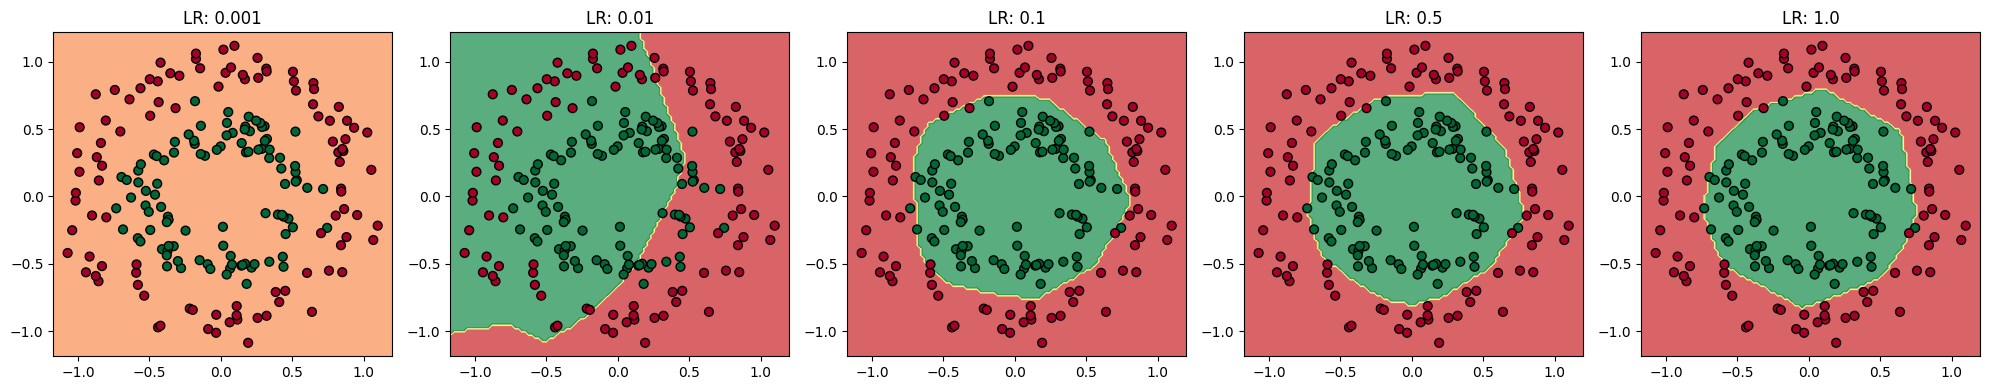

In [ ]:
plt.figure(figsize=(20, 4))
lrs = [0.001, 0.01, 0.1, 0.5, 1.0]
results_lr = []

for i, lr in enumerate(lrs):
    model = CircleModelV0(hidden_units=10)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    for epoch in range(800):
        model.train()
        logits = model(X_train).squeeze()
        loss = loss_fn(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # точность на тесте
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        acc = accuracy_fn(y_test, test_preds)
        results_lr.append({"Learning Rate": lr, "Final Loss": loss.item(), "Test Accuracy": acc})

    # график кривой прогнозирования
    plt.subplot(1, 5, i+1)
    plot_decision_boundary(model, X_test, y_test)
    plt.title(f"LR: {lr}")

df_lr = pd.DataFrame(results_lr)
print(df_lr)
plt.tight_layout()
plt.show()

* LR = 0.001: самая низкая точность, значение ошибки высокое. На графике фон закрашен одним цветом, разделяющая граница отсутствует. Шаг градиентного спуска слишком мал, модель не успела начать обучение.
* LR = 0.01: точность выросла до 62%, Loss снизился. Появилась грубая попытка провести границу. Модель начала учиться, но скорость всё еще недостаточна.
* LR = 0.1: скачок точности до 97.5%, Loss упал до 0.038. Видна замкнутая нелинейная граница, которая отделяет внутренний круг от внешнего. Это хороший баланс, шаг обучения позволяет модели быстро и стабильно спускаться к минимуму функции потерь.
* LR = 0.5 и 1.0: точность достигла максимума 98%, Loss минимальный. Граница четкая, но стала чуть более угловатой по сравнению с LR=0.1. Модель обучается очень быстро, но большие шаги могут приводить к тому, что оптимизатор перепрыгивает через идеальный минимум.

Learning Rate — важный гиперпараметр, его занижение делает обучение невозможным за разумное время, а выбор оптимального значения позволяет получить качественный нелинейный классификатор. В данном случае оптимальным будет значение 0.1.

Hidden Units

   Нейроны  Final Loss  Test Accuracy
0        2    0.602659           59.5
1        5    0.206966           94.0
2       10    0.044239           98.5
3       20    0.026037           98.0
4       50    0.017569           98.0


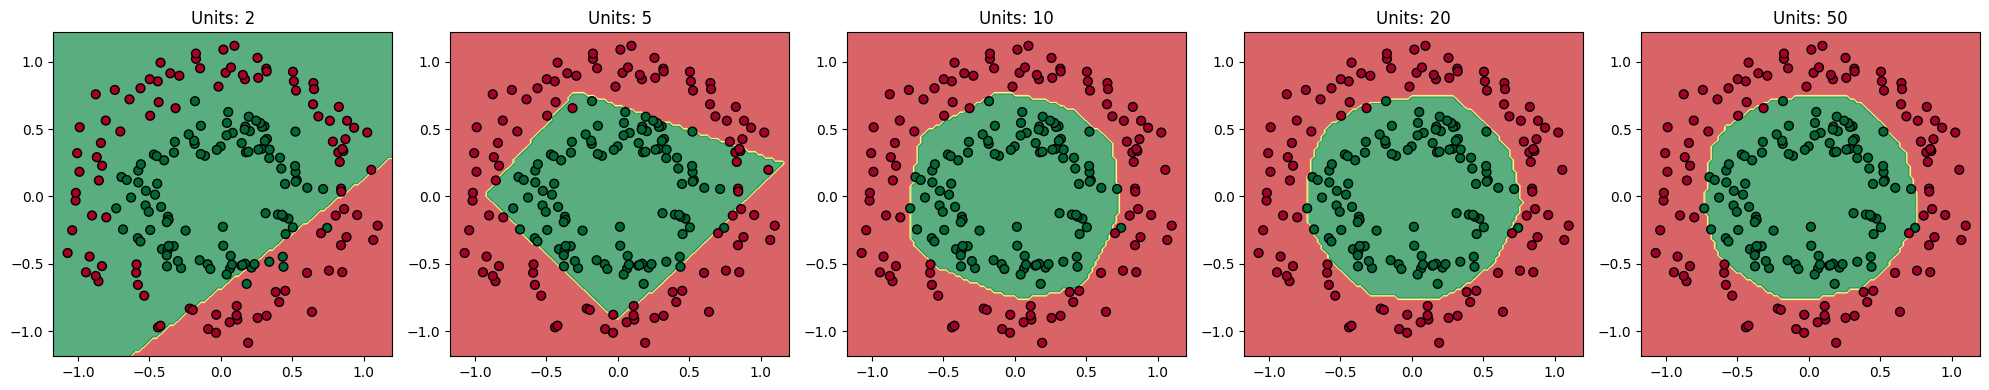

In [ ]:
plt.figure(figsize=(20, 4))
neuron_variants = [2, 5, 10, 20, 50]
neuron_results = []

for i, units in enumerate(neuron_variants):
    model = CircleModelV0(hidden_units=units)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(1000):
        model.train()
        logits = model(X_train).squeeze()
        loss = loss_fn(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # точность на тесте
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        acc = accuracy_fn(y_test, test_preds)

    neuron_results.append({"Нейроны": units, "Final Loss": loss.item(), "Test Accuracy": acc})

    # график кривой прогнозирования
    plt.subplot(1, 5, i+1)
    plot_decision_boundary(model, X_test, y_test)
    plt.title(f"Units: {units}")

df_neurons = pd.DataFrame(neuron_results)
print(df_neurons)

plt.tight_layout()
plt.show()

* Units 2: точность всего 59.5%, Loss высокий. На графике почти прямая линия. Двух нейронов недостаточно, чтобы замкнуть круг. Модель пытается разделить данные простым способом, но задача требует нелинейного решения.
* Units 5: точность резко подскочила до 94%. Разделяющая граница приобрела форму четырехугольника, модель начала понимать структуру данных. Пяти нейронов уже достаточно, чтобы выделить центральную область, хотя граница еще очень грубая.
* Units 10: точность самая высокая 98.5%. Граница стала многоугольной и плавно огибает внутренний кластер. Модель обладает достаточным количеством параметров, чтобы уверенно описать форму круга, не переусложняя вычисления.
* Units 20 и 50: точность стабилизировалась на уровне 98%, граница становится еще более гладкой и детальной. Увеличение количества нейронов выше 10 в данной задаче уже не дает существенного прироста точности. Модель тратит больше вычислительных ресурсов только на уточнение мелких деталей границы.

Малое количество нейронов ограничивает модель простыми формами, а увеличение их числа позволяет описывать сложные нелинейные зависимости. Для данной задачи оптимальным является использование 10 нейронов.

## 4. Два новых класса моделей

Создадим два других класса моделей с некоторыми архитектурными отличиями.

Модель №2: в первой модели было 2 скрытых слоя, добавим третий.

Модель №3: в первой модели было по 10 нейронов, сделаем один скрытый слой, но в нем будет сразу 100 нейронов.

In [13]:
# Модель №2 (3 скрытых слоя)
class CircleModelDeep(nn.Module):
    def __init__(self, hidden_units):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=hidden_units)
        self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer_3 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer_4 = nn.Linear(in_features=hidden_units, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        return self.layer_4(x)

# Модель №3 (1 скрытый слой)
class CircleModelWide(nn.Module):
    def __init__(self, hidden_units):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=hidden_units)
        self.layer_2 = nn.Linear(in_features=hidden_units, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_2(self.relu(self.layer_1(x)))

model_deep = CircleModelDeep(hidden_units=10)
model_wide = CircleModelWide(hidden_units=100)

def final_test(model, name):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(801):
        model.train()
        logits = model(X_train).squeeze()
        loss = loss_fn(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.inference_mode():
        acc = accuracy_fn(y_test, torch.round(torch.sigmoid(model(X_test).squeeze())))
    print(f"Архитектура {name} завершила обучение. Accuracy: {acc:.2f}%")

final_test(model_deep, "Deep (3 скрытых слоя)")
final_test(model_wide, "Wide (100 нейронов в 1 слое)")

Архитектура Deep (3 скрытых слоя) завершила обучение. Accuracy: 97.50%
Архитектура Wide (100 нейронов в 1 слое) завершила обучение. Accuracy: 98.00%




Посмотрим как изменились графики с разделяющей границей.

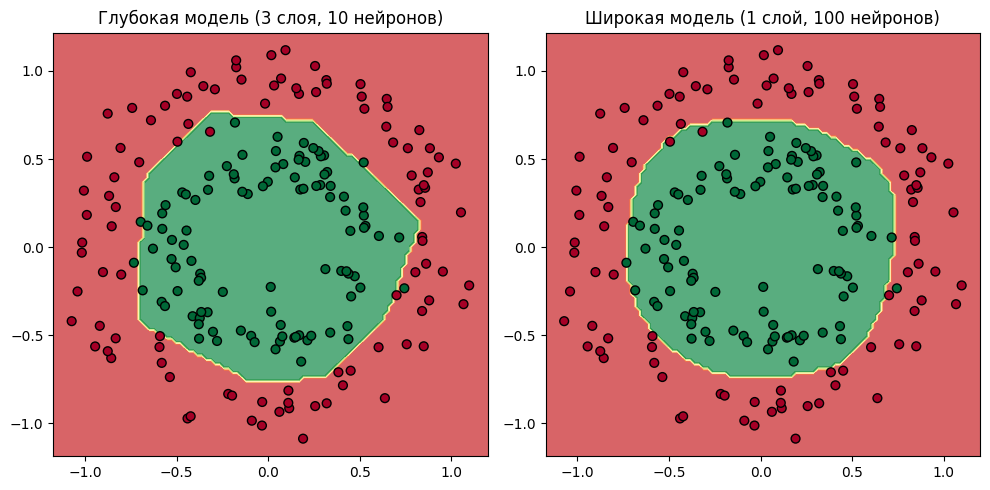

In [16]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(model_deep, X_test, y_test)
plt.title("Глубокая модель (3 слоя, 10 нейронов)")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_wide, X_test, y_test)
plt.title("Широкая модель (1 слой, 100 нейронов)")

plt.tight_layout()
plt.show()

Обе модели достигли высокой точности (97.5% и 98.0%), но пришли к этому результату через разные геометрические стратегии.

На графике глкбокой модели решающая граница имеет форму четкого многоугольника. Каждый слой действует как фильтр, первый находит грубые границы, второй их уточняет, третий сглаживает углы.

На графике широкой модели граница выглядит более округлой и гладкой, состоит из огромного количества маленьких отрезков. Поскольку в слое сразу 100 нейронов, каждый из них отвечает за свой маленький участок круга. Это дает плавный переход, но требует больше параметров в одном слое.

## Вывод

В ходе выполнения данной работы были изучены построение и обучение простейших нейронных сетей. Для экспериментов был выбран синтетический датасет, который отражает проблему линейных моделей: невозможность разделить данные одной прямой линией. Созданная модель успешно справилась с этой задачей, достигнув точности в 98%. Построение графиков разделяющей границы помогло увидеть, как нейросеть принимает решения.

В ходе экспериментов была оценена важность гиперпараметров. Скорость обучения Learning Rate один из важнейших из них, слишком малый шаг делает обучение бесконечным, а слишком большой может привести к нестабильности. Оптимальным для данной задачи оказался уровень 0.1. Количество нейронов также серьезно влияет на качеством прогноза. Например, 2 нейрона не могут построить сложную фигуру, а 10 и более позволяют создать достаточно гибкую границу для точной классификации.

Построение дополнительных моделей с небольшим изменением архитектуры показало, что задачу можно решить разными путями. Один очень широкий слой справляется так же хорошо, как глубокая сеть, однако глубокие сети тратят меньше памяти для достижения той же точности. Для эффективного решения задачи необходим баланс между этими параметрами.

Работа показала, что даже простая архитектура нейронной сети при правильном подборе параметров способна эффективно решать задачи нелинейной классификации. Библиотека PyTorch удобна для таких экспериментов благодаря гибкости настройки слоев и автоматизации расчетов.